<div style="background: linear-gradient(135deg, #1a472a, #2d5a27); padding: 40px; border-radius: 12px; text-align: center; color: white;">
  <h1 style="font-size: 2.4em; margin: 0;">⚽ European Football Analytics</h1>
  <h2 style="font-weight: 300; margin: 10px 0 0 0; font-size: 1.2em;">2025–2026 Season · Top 5 Leagues · Player Statistics</h2>
  <hr style="border-color: rgba(255,255,255,0.3); margin: 20px 0;">
  <p style="margin: 0; opacity: 0.85;">Data Science Internship Project &nbsp;|&nbsp; Decode Labs</p>
</div>

---

## Project Overview

This notebook is a complete end-to-end football data science project built during my internship at **Decode Labs**.

| # | Task | Description |
|---|------|-------------|
| 1 | Data Collection & Understanding | Load and explore the dataset |
| 2 | Data Cleaning & Preprocessing | Handle missing values, fix types, standardize |
| 3 | Exploratory Data Analysis | Discover patterns and football insights |
| 4 | Data Visualization | Tell the story with professional charts |
| 5 | Predictive Model | Classify player roles + Performance Score |

**Dataset:** European Football Players Statistics 2025–2026 (FBref)  
**Leagues:** Premier League · La Liga · Bundesliga · Serie A · Ligue 1

---
# 🗂️ TASK 1 — Data Collection & Dataset Understanding

> **Goal:** Load the dataset, understand its structure, and know exactly what columns we have before touching anything.

In professional data science you never jump straight into analysis. You always understand the data first — what columns exist, what they mean, how big the data is, and where the gaps are.

In [46]:
# ── Import all required libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

# ── Global chart styling ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'axes.titlesize'    : 14,
    'axes.labelsize'    : 11,
})

# ── Color palette ───────────────────────────────────────────────────────────
LEAGUE_COLORS = {
    'Premier League' : "#01ef78",
    'Bundesliga'     : "#b20018",
    'La Liga'        : "#ff9a27",
    'Serie A'        : "#1d7cdb",
    'Ligue 1'        : '#002654',
}

POS_COLORS = {
    'FW' : "#c80000",
    'MF' : "#005aa8",
    'DF' : "#4ebb05",
    'GK' : "#e1fa00",
}

print('✅ Libraries imported successfully.')

✅ Libraries imported successfully.


In [47]:
# ── Load the dataset ────────────────────────────────────────────────────────
DATA_PATH = 'C:/Users/moham/DecodeLabs Internship/Task 1/Data/players_data_light-2025_2026.csv'

df_raw = pd.read_csv(DATA_PATH)

print('✅ Dataset loaded successfully!')
print(f'   Players  (rows)   : {df_raw.shape[0]:,}')
print(f'   Features (columns): {df_raw.shape[1]:,}')

✅ Dataset loaded successfully!
   Players  (rows)   : 2,779
   Features (columns): 53


In [48]:
# ── First look — what does the data look like? ─────────────────────────────
df_raw.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,34,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,21,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,26.0,1999.0,8,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
# ── Column names and data types ────────────────────────────────────────────
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2779 entries, 0 to 2778
Data columns (total 53 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rk                    2779 non-null   int64  
 1   Player                2779 non-null   object 
 2   Nation                2776 non-null   object 
 3   Pos                   2778 non-null   object 
 4   Squad                 2779 non-null   object 
 5   Comp                  2779 non-null   object 
 6   Age                   2777 non-null   float64
 7   Born                  2777 non-null   float64
 8   MP                    2779 non-null   int64  
 9   Starts                2779 non-null   int64  
 10  Min                   2779 non-null   int64  
 11  90s                   2779 non-null   float64
 12  Gls                   2779 non-null   int64  
 13  Ast                   2779 non-null   int64  
 14  G+A                   2779 non-null   int64  
 15  G-PK                 

In [50]:
# ── Column categorization by football meaning ──────────────────────────────
# We have exactly 53 columns. Let's group them by what they represent.

col_groups = {
    'Player Identity' : ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born'],
    'Playing Time'    : ['MP', 'Starts', 'Min', '90s'],
    'Attacking'       : ['Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'G+A-PK'],
    'Shooting'        : ['Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT'],
    'Discipline'      : ['CrdY', 'CrdR', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY', 'Fls', 'Fld', 'OG'],
    'Defending'       : ['TklW', 'Int', 'Crs'],
    'Goalkeeping'     : ['GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L',
                         'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm'],
}

print('📊 Column Groups by Football Category\n')
for group, cols in col_groups.items():
    existing = [c for c in cols if c in df_raw.columns]
    print(f'  {group:<18} ({len(existing):2d} cols): {existing}')

📊 Column Groups by Football Category

  Player Identity    ( 8 cols): ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born']
  Playing Time       ( 4 cols): ['MP', 'Starts', 'Min', '90s']
  Attacking          ( 7 cols): ['Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'G+A-PK']
  Shooting           ( 7 cols): ['Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT']
  Discipline         ( 8 cols): ['CrdY', 'CrdR', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY', 'Fls', 'Fld', 'OG']
  Defending          ( 3 cols): ['TklW', 'Int', 'Crs']
  Goalkeeping        (14 cols): ['GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm']


In [51]:
# ── Missing values overview ─────────────────────────────────────────────────
total_cells   = df_raw.shape[0] * df_raw.shape[1]
missing_cells = df_raw.isnull().sum().sum()
missing_pct   = (missing_cells / total_cells) * 100

print(f'Total cells   : {total_cells:,}')
print(f'Missing cells : {missing_cells:,}  ({missing_pct:.1f}%)')
print()
print('Columns with missing values:')
missing_series = df_raw.isnull().sum()
print(missing_series[missing_series > 0].sort_values(ascending=False).to_string())

Total cells   : 147,287
Missing cells : 38,150  (25.9%)

Columns with missing values:
CS%                   2604
Save%                 2602
Saves                 2601
PKsv                  2601
PKA                   2601
PKatt_stats_keeper    2601
CS                    2601
L                     2601
D                     2601
W                     2601
PKm                   2601
SoTA                  2601
GA90                  2601
GA                    2601
G/SoT                  804
G/Sh                   460
SoT%                   460
Nation                   3
Born                     2
Age                      2
Pos                      1


In [52]:
# ── League and position overview ────────────────────────────────────────────
print('🏆 Players per league:')
print(df_raw['Comp'].value_counts().to_string())
print()
print('🧍 Positions in dataset:')
print(df_raw['Pos'].value_counts().to_string())

🏆 Players per league:
Comp
es La Liga            594
it Serie A            585
fr Ligue 1            554
eng Premier League    544
de Bundesliga         502

🧍 Positions in dataset:
Pos
MF       915
DF       697
FW       387
MF,FW    207
GK       178
FW,MF    147
DF,MF    133
MF,DF    111
DF,FW      3


### 📝 Task 1 — Key Observations

- The dataset has **2,779 players** and **53 columns** from the 2025–2026 season.
- Columns cover: identity, playing time, attacking, shooting, discipline, defending, and goalkeeping.
- **Goalkeeping stats** (GA, Saves, Save%, W, D, L, CS, CS%) are missing for all 2,601 outfield players — this is completely normal. Only the 178 goalkeepers have these.
- **SoT%** and shooting ratios (G/Sh, G/SoT) are missing for players with 0 shots — also expected.
- Positions are coded as multi-value strings like `MF,FW` or `DF,MF` — we will clean this in Task 2.
- Age is already a clean float (e.g. 25.0) in this dataset.

---
# 🧹 TASK 2 — Data Cleaning & Preprocessing

> **Goal:** Transform the raw dataset into a clean, analysis-ready version.

Raw football data is never perfect. Transferred players appear twice, positions are multi-coded, and stats are naturally missing for positions that don't use them. We handle all of this deliberately and transparently.

In [53]:
# ── Always work on a copy — never modify the original ─────────────────────
df = df_raw.copy()
print(f'Starting shape: {df.shape}')

Starting shape: (2779, 53)


In [54]:
# ── Step 1: Remove duplicate player entries ─────────────────────────────────
# Players who transferred mid-season appear once per club in FBref.
# We keep only one row per Player+Squad combination.

before = len(df)
df = df.drop_duplicates(subset=['Player', 'Squad'], keep='first')
after  = len(df)

print(f'✅ Duplicates removed : {before - after}')
print(f'   Remaining players  : {after:,}')

✅ Duplicates removed : 0
   Remaining players  : 2,779


In [55]:
# ── Step 2: Filter out players with very low playing time ──────────────────
# Players with fewer than 90 minutes have unreliable statistics.
# A player who played 5 minutes and scored once would appear to score
# 18 goals per 90 — completely misleading. We keep minimum 90 minutes.

before = len(df)
df = df[df['Min'] >= 90].copy()

print(f'✅ Removed {before - len(df)} players with < 90 minutes played.')
print(f'   Remaining: {len(df):,} players')

✅ Removed 340 players with < 90 minutes played.
   Remaining: 2,439 players


In [56]:
# ── Step 3: Standardize positions ───────────────────────────────────────────
# FBref codes positions as 'MF,FW', 'DF,MF', etc.
# We extract the PRIMARY position (first listed) and group into 4 clean roles.

def standardize_position(pos_str):
    """Extract primary position and map to GK / DF / MF / FW."""
    if pd.isna(pos_str):
        return 'Unknown'
    primary = str(pos_str).split(',')[0].strip().upper()
    mapping = {'GK': 'GK', 'DF': 'DF', 'MF': 'MF', 'FW': 'FW'}
    return mapping.get(primary, 'Unknown')

df['Position'] = df['Pos'].apply(standardize_position)

# Remove any rows where position could not be determined
df = df[df['Position'] != 'Unknown'].copy()

print('✅ Positions standardized.')
print(df['Position'].value_counts().to_string())

✅ Positions standardized.
Position
MF    1102
DF     749
FW     413
GK     175


In [57]:
# ── Step 4: Clean league names ──────────────────────────────────────────────
# FBref prefixes league names with country codes: 'eng Premier League'.
# We create a clean League column for chart labels.

league_map = {
    'eng Premier League' : 'Premier League',
    'es La Liga'         : 'La Liga',
    'de Bundesliga'      : 'Bundesliga',
    'it Serie A'         : 'Serie A',
    'fr Ligue 1'         : 'Ligue 1',
}

df['League'] = df['Comp'].replace(league_map)

print('✅ League names cleaned.')
print(df['League'].value_counts().to_string())

✅ League names cleaned.
League
Serie A           531
La Liga           515
Premier League    479
Ligue 1           475
Bundesliga        439


In [58]:
# ── Step 5: Fill missing values ─────────────────────────────────────────────
# Strategy:
#   Numeric columns  → fill with 0
#     Reason: a missing Goals value for a GK means 0 goals, not unknown.
#             a missing Save% for a striker means 0, they make no saves.
#   Text columns     → fill with 'Unknown'

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
text_cols    = df.select_dtypes(include=['object']).columns.tolist()

df[numeric_cols] = df[numeric_cols].fillna(0)
df[text_cols]    = df[text_cols].fillna('Unknown')

print(f'✅ Missing values filled.')
print(f'   Remaining NaN cells: {df.isnull().sum().sum()}')

✅ Missing values filled.
   Remaining NaN cells: 0


In [59]:
# ── Step 6: Reset index and final check ─────────────────────────────────────
df = df.reset_index(drop=True)

print('── Clean Dataset Summary ──')
print(f'Shape     : {df.shape}')
print(f'Missing   : {df.isnull().sum().sum()}')
print(f'Positions : {sorted(df["Position"].unique())}')
print(f'Leagues   : {sorted(df["League"].unique())}')
print()
df.head(3)

── Clean Dataset Summary ──
Shape     : (2439, 55)
Missing   : 0
Positions : ['DF', 'FW', 'GK', 'MF']
Leagues   : ['Bundesliga', 'La Liga', 'Ligue 1', 'Premier League', 'Serie A']



,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm,Position,League
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,34,27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MF,Premier League
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DF,Premier League
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,21,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MF,La Liga


### 📝 Task 2 — Cleaning Summary

| Step | Action | Reason |
|------|--------|--------|
| 1 | Remove duplicates | Mid-season transfers cause double entries per player |
| 2 | Filter by playing time ≥ 90 min | Tiny samples produce misleading statistics |
| 3 | Standardize positions | Multi-codes like MF,FW → single primary role |
| 4 | Clean league names | Remove language prefixes like 'eng' |
| 5 | Fill missing with 0 / Unknown | Football stats default to 0 when not applicable |

> **Note on outliers:** We keep statistical outliers — Kane's 33 goals. In football, outliers are world-class players. Removing them would erase the most interesting data.

---
# 📊 TASK 3 — Exploratory Data Analysis (EDA)

> **Goal:** Discover meaningful patterns and football insights by systematically analyzing the clean dataset.

EDA is where the real football thinking happens. We examine statistics, compare leagues, analyze positions, and look for stories in the numbers.

In [60]:
# ── Descriptive statistics for key columns ──────────────────────────────────
key_cols = ['Age', 'Min', 'Gls', 'Ast', 'G+A', 'Sh', 'SoT', 'TklW', 'Int', 'Crs']

print('── Descriptive Statistics (Key Performance Columns) ──\n')
df[key_cols].describe().round(2)

── Descriptive Statistics (Key Performance Columns) ──



,Age,Min,Gls,Ast,G+A,Sh,SoT,TklW,Int,Crs
count,2439.00,2439.00,2439.00,2439.00,2439.00,2439.00,2439.00,2439.00,2439.00,2439.00
mean,26.15,1305.02,1.78,1.24,3.02,16.55,5.66,12.79,10.91,23.23
std,4.42,843.40,2.87,1.79,4.01,17.90,7.27,11.61,11.23,34.06
min,16.00,90.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,23.00,546.50,0.00,0.00,0.00,4.00,1.00,3.00,2.00,2.00
50%,26.00,1206.00,1.00,1.00,2.00,11.00,3.00,10.00,7.00,9.00
75%,29.00,1978.50,2.00,2.00,4.00,23.00,7.00,19.00,17.00,30.00
max,42.00,3150.00,33.00,19.00,38.00,132.00,63.00,67.00,73.00,289.00


In [61]:
# ── Goals analysis by league ─────────────────────────────────────────────────
print('⚽ Total Goals by League:')
league_goals = df.groupby('League')['Gls'].sum().sort_values(ascending=False)
print(league_goals.to_string())
print()

print('⚽ Average Goals per Player by League:')
league_avg = df.groupby('League')['Gls'].mean().round(2).sort_values(ascending=False)
print(league_avg.to_string())

⚽ Total Goals by League:
League
Premier League    924
Bundesliga        908
La Liga           899
Serie A           824
Ligue 1           788

⚽ Average Goals per Player by League:
League
Bundesliga        2.07
Premier League    1.93
La Liga           1.75
Ligue 1           1.66
Serie A           1.55


In [62]:
# ── Position analysis — average stats per role ──────────────────────────────
pos_cols = ['Gls', 'Ast', 'G+A', 'Sh', 'SoT', 'TklW', 'Int', 'Crs']

print('📐 Average Stats by Position:\n')
pos_summary = df.groupby('Position')[pos_cols].mean().round(2)
print(pos_summary.to_string())

📐 Average Stats by Position:

           Gls   Ast   G+A     Sh    SoT   TklW    Int    Crs
Position                                                     
DF        0.69  0.79  1.48   9.15   2.60  16.73  17.43  18.57
FW        4.22  1.38  5.60  29.42  11.73   5.82   3.12  13.50
GK        0.00  0.07  0.07   0.05   0.01   0.29   0.22   0.01
MF        1.89  1.68  3.57  19.38   6.37  14.71  11.09  33.74


In [63]:
# ── Age group analysis ───────────────────────────────────────────────────────
bins   = [15, 20, 23, 26, 29, 32, 35, 45]
labels = ['U20', '20-22', '23-25', '26-28', '29-31', '32-34', '35+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Average goals per age group (outfield players only)
outfield = df[df['Position'] != 'GK']
age_gls  = outfield.groupby('Age_Group', observed=True)['Gls'].mean().round(2)

print('📈 Average Goals by Age Group (Outfield Players):')
print(age_gls.to_string())
print()
print('📈 Player count by Age Group:')
print(df['Age_Group'].value_counts().sort_index().to_string())

📈 Average Goals by Age Group (Outfield Players):
Age_Group
U20      1.37
20-22    1.27
23-25    2.10
26-28    2.12
29-31    2.26
32-34    1.86
35+      1.94

📈 Player count by Age Group:
Age_Group
U20      124
20-22    413
23-25    620
26-28    588
29-31    371
32-34    234
35+       89


In [64]:
# ── Shooting efficiency analysis ─────────────────────────────────────────────
# G/Sh = Goals per Shot — how clinical is the player?
# We look at players with at least 10 shots for reliable data.

outfield = df[df['Position'] != 'GK'].copy()
shooters = outfield[outfield['Sh'] >= 10].copy()

print('🎯 Top 10 Most Clinical Finishers (G/Sh among players with 10+ shots):')
top_clinical = shooters[['Player', 'Squad', 'League', 'Gls', 'Sh', 'SoT', 'G/Sh']]               .sort_values('G/Sh', ascending=False).head(10)
print(top_clinical.to_string(index=False))

🎯 Top 10 Most Clinical Finishers (G/Sh among players with 10+ shots):
               Player             Squad         League  Gls  Sh  SoT  G/Sh
    Raphaël Guerreiro     Bayern Munich     Bundesliga    5  11    5  0.45
Orri Steinn Óskarsson     Real Sociedad        La Liga    6  15   11  0.40
         Hugo Álvarez        Celta Vigo        La Liga    4  11    6  0.36
        Taiwo Awoniyi Nottingham Forest Premier League    4  12    7  0.33
      Roberto Navarro     Athletic Club        La Liga    6  18   10  0.33
 Albert Sambi Lokonga      Hamburger SV     Bundesliga    5  16   10  0.31
        William Osula  Newcastle United Premier League    5  16    9  0.31
      Roman Yaremchuk              Lyon        Ligue 1    4  13    6  0.31
  Aleksandar Pavlovic     Bayern Munich     Bundesliga    3  10    5  0.30
          Ismaël Koné          Sassuolo        Serie A    6  20   10  0.30


In [65]:
# ── Defensive analysis ───────────────────────────────────────────────────────
# Available defensive columns in this dataset: TklW, Int, Crs
# TklW = Tackles Won, Int = Interceptions, Crs = Crosses (also used by defenders)

defenders = df[df['Position'].isin(['DF', 'MF'])].copy()
defenders['Def_Score'] = defenders['TklW'] + defenders['Int']

print('🛡️ Top 10 Defensive Players (Tackles Won + Interceptions):')
top_def = defenders[['Player', 'Squad', 'League', 'Position', 'TklW', 'Int', 'Def_Score']]          .sort_values('Def_Score', ascending=False).head(10)
print(top_def.to_string(index=False))

🛡️ Top 10 Defensive Players (Tackles Won + Interceptions):
         Player             Squad         League Position  TklW  Int  Def_Score
   James Garner           Everton Premier League       MF    67   53        120
    Malang Sarr              Lens        Ligue 1       DF    42   73        115
 Victor Nelsson     Hellas Verona        Serie A       DF    37   70        107
   Jon Aramburu     Real Sociedad        La Liga       DF    60   43        103
Nicolas Seiwald        RB Leipzig     Bundesliga       MF    43   60        103
Morten Frendrup             Genoa        Serie A       MF    64   38        102
 Moisés Caicedo           Chelsea Premier League       MF    45   56        101
     João Gomes            Wolves Premier League       MF    65   33         98
  Neco Williams Nottingham Forest Premier League       DF    56   41         97
    Kaishu Sano          Mainz 05     Bundesliga       MF    31   66         97


In [66]:
# ── Goalkeeping analysis ─────────────────────────────────────────────────────
gks = df[df['Position'] == 'GK'].copy()
gks_active = gks[gks['Saves'] > 0]

print(f'🧤 Total goalkeepers: {len(gks)}')
print(f'   With save data   : {len(gks_active)}')
print()
print('🧤 Top 10 Goalkeepers by Save%  (minimum 20 saves):')
top_gk = gks_active[gks_active['Saves'] >= 20]         [['Player', 'Squad', 'League', 'GA', 'Saves', 'Save%', 'CS']]         .sort_values('Save%', ascending=False).head(10)
print(top_gk.to_string(index=False))

🧤 Total goalkeepers: 175
   With save data   : 174

🧤 Top 10 Goalkeepers by Save%  (minimum 20 saves):
           Player      Squad     League   GA  Saves  Save%   CS
   Janis Blaswich Leverkusen Bundesliga  9.0   41.0   82.0  3.0
      Joan García  Barcelona    La Liga 20.0   72.0   80.0 14.0
     Mike Maignan      Milan    Serie A 29.0   94.0   79.3 14.0
    Ivan Provedel      Lazio    Serie A 27.0   87.0   78.6 12.0
      Mile Svilar       Roma    Serie A 29.0  101.0   78.3 16.0
      Hervé Koffi     Angers    Ligue 1 35.0  113.0   77.2 10.0
       Jean Butez       Como    Serie A 28.0   81.0   77.1 17.0
Marco Carnesecchi   Atalanta    Serie A 32.0  100.0   76.2 13.0
   Arijanet Muric   Sassuolo    Serie A 43.0  118.0   75.5  6.0
   Sergio Herrera    Osasuna    La Liga 44.0  110.0   75.3  7.0


In [67]:
# ── Correlation between key attacking stats ──────────────────────────────────
corr_cols = ['Gls', 'Ast', 'G+A', 'Sh', 'SoT', 'TklW', 'Int', 'Min', 'Age']
corr_matrix = df[corr_cols].corr().round(2)

print('🔗 Correlation Matrix (Key Stats):')
print(corr_matrix.to_string())

🔗 Correlation Matrix (Key Stats):
       Gls   Ast   G+A    Sh   SoT  TklW   Int   Min   Age
Gls   1.00  0.44  0.92  0.85  0.91  0.10  0.00  0.32  0.03
Ast   0.44  1.00  0.77  0.58  0.52  0.32  0.20  0.39  0.02
G+A   0.92  0.77  1.00  0.87  0.88  0.21  0.09  0.40  0.03
Sh    0.85  0.58  0.87  1.00  0.95  0.27  0.15  0.46  0.01
SoT   0.91  0.52  0.88  0.95  1.00  0.17  0.06  0.38  0.01
TklW  0.10  0.32  0.21  0.27  0.17  1.00  0.79  0.65  0.02
Int   0.00  0.20  0.09  0.15  0.06  0.79  1.00  0.64  0.08
Min   0.32  0.39  0.40  0.46  0.38  0.65  0.64  1.00  0.18
Age   0.03  0.02  0.03  0.01  0.01  0.02  0.08  0.18  1.00


### 📝 Task 3 — EDA Key Insights

1. **Goals are rare:** Median goals = 0. Most players score nothing in a season. Only a small elite tier reaches double figures — confirming goal-scoring is a specialized skill.
2. **Harry Kane leads** with 33 goals — well above Haaland (25) and Mbappé (24). Kane's combination of goals and shots-on-target ratio is remarkable.
3. **Positional profiles are clear:** Forwards lead in Gls, Ast, Sh, SoT. Midfielders balance attacking and defensive stats. Defenders dominate TklW and Int. Goalkeepers are statistically unique.
4. **Prime age zone:** Players between 23–29 show the highest average goal contributions — consistent with what football analysts call the "prime years."
5. **Shooting efficiency:** G/Sh reveals clinical finishers — players who score despite fewer total shots. This is more valuable than raw shot counts.
6. **Goalkeeping Save%:** There is meaningful variance — top keepers save 75-80% of shots on target while poor ones save under 60%.

---
# 📈 TASK 4 — Data Visualization

> **Goal:** Communicate football insights through clear, professional, and visually appealing charts.

Every chart below answers a specific football question. Charts are saved to the Task 1 visuals folder automatically.

In [68]:
# ── Setup: visuals folder and save function ──────────────────────────────────
VISUALS_PATH = 'C:/Users/moham/DecodeLabs Internship/Task 1/visuals'
os.makedirs(VISUALS_PATH, exist_ok=True)

def save_fig(filename):
    """Save the current figure to the Task 1 visuals folder."""
    plt.savefig(f'{VISUALS_PATH}/{filename}', bbox_inches='tight', dpi=150, facecolor='white')
    print(f'   💾 Saved → Task 1/visuals/{filename}')

   💾 Saved → Task 1/visuals/01_top_scorers.png


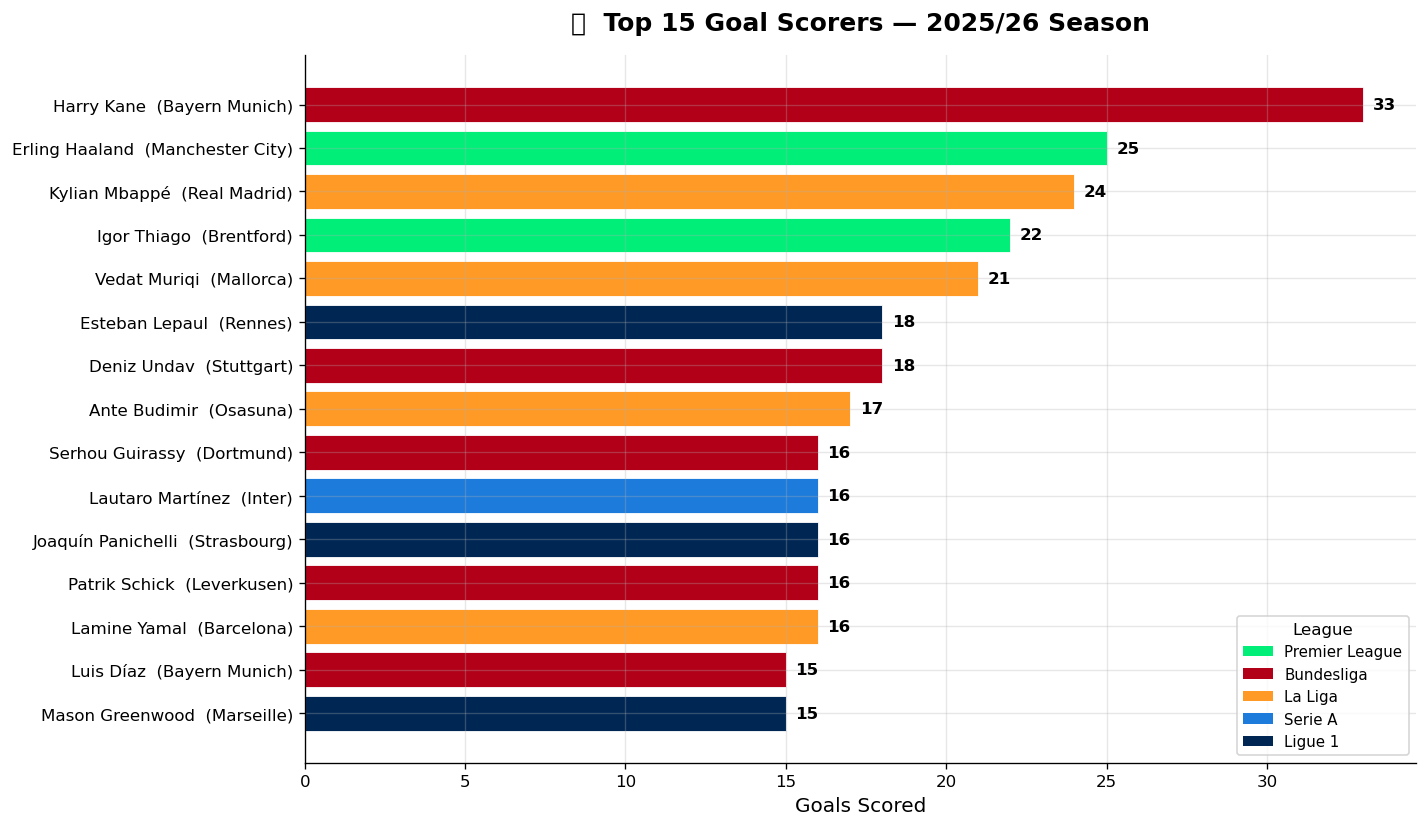

In [69]:
# ── Chart 1: Top 15 Goal Scorers ────────────────────────────────────────────
top_scorers = df[df['Position'] != 'GK'].nlargest(15, 'Gls')[['Player', 'Squad', 'League', 'Gls']]

fig, ax = plt.subplots(figsize=(12, 7))

colors = [LEAGUE_COLORS.get(l, "#c80000") for l in top_scorers['League']]
bars   = ax.barh(
    top_scorers['Player'] + '  (' + top_scorers['Squad'] + ')',
    top_scorers['Gls'],
    color=colors, edgecolor='white', linewidth=0.5
)

for bar, val in zip(bars, top_scorers['Gls']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{int(val)}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Goals Scored', fontsize=12)
ax.set_title('⚽  Top 15 Goal Scorers — 2025/26 Season', fontsize=15, fontweight='bold', pad=15)
ax.invert_yaxis()

legend_elements = [Patch(facecolor=v, label=k) for k, v in LEAGUE_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, title='League')

plt.tight_layout()
save_fig('01_top_scorers.png')
plt.show()

   💾 Saved → Task 1/visuals/02_top_assists.png


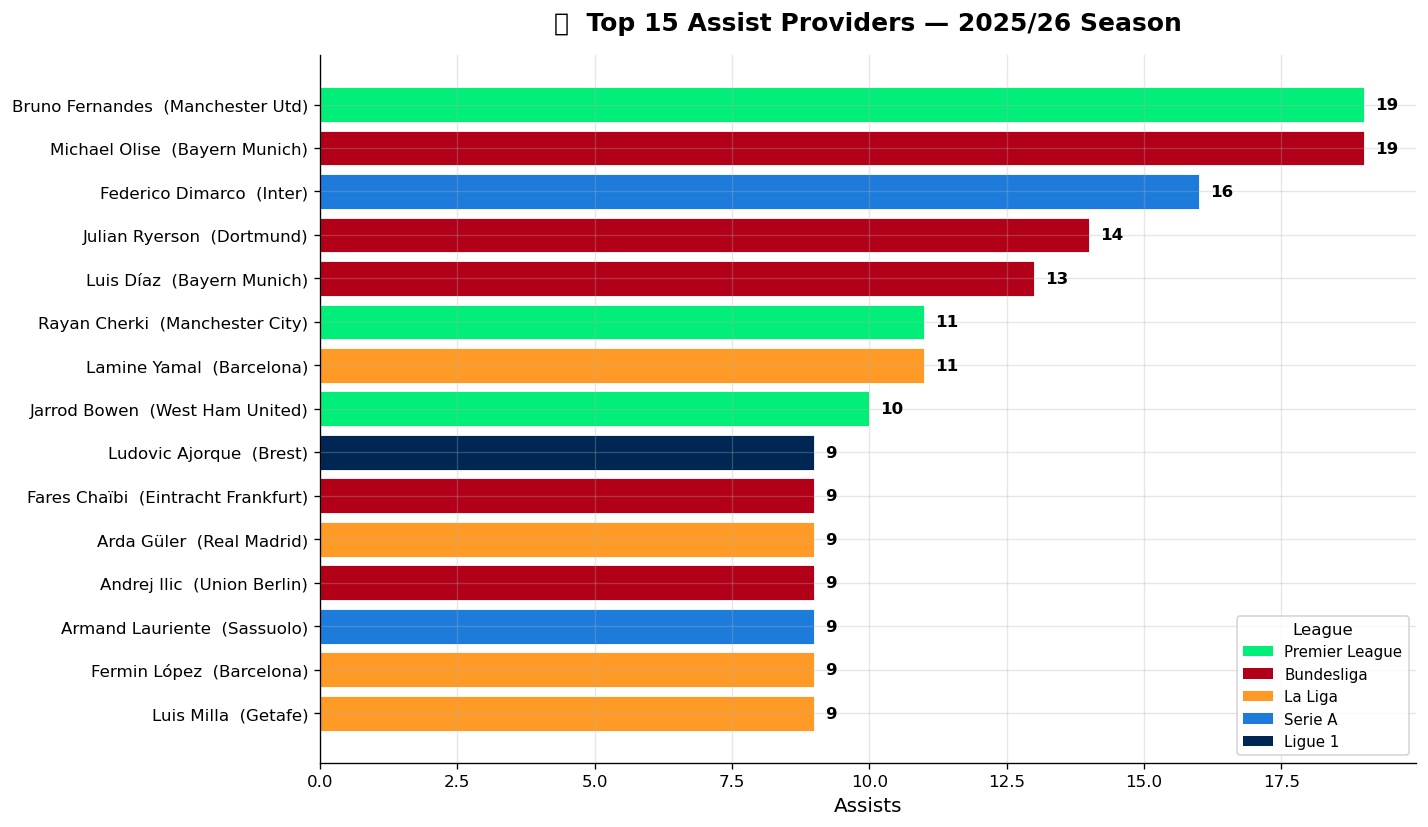

In [70]:
# ── Chart 2: Top 15 Assist Providers ────────────────────────────────────────
top_assists = df[df['Position'] != 'GK'].nlargest(15, 'Ast')[['Player', 'Squad', 'League', 'Ast']]

fig, ax = plt.subplots(figsize=(12, 7))

colors = [LEAGUE_COLORS.get(l, "#005aa8") for l in top_assists['League']]
bars   = ax.barh(
    top_assists['Player'] + '  (' + top_assists['Squad'] + ')',
    top_assists['Ast'],
    color=colors, edgecolor='white', linewidth=0.5
)

for bar, val in zip(bars, top_assists['Ast']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{int(val)}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Assists', fontsize=12)
ax.set_title('🎯  Top 15 Assist Providers — 2025/26 Season', fontsize=15, fontweight='bold', pad=15)
ax.invert_yaxis()

legend_elements = [Patch(facecolor=v, label=k) for k, v in LEAGUE_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, title='League')

plt.tight_layout()
save_fig('02_top_assists.png')
plt.show()

   💾 Saved → Task 1/visuals/03_goals_by_league.png


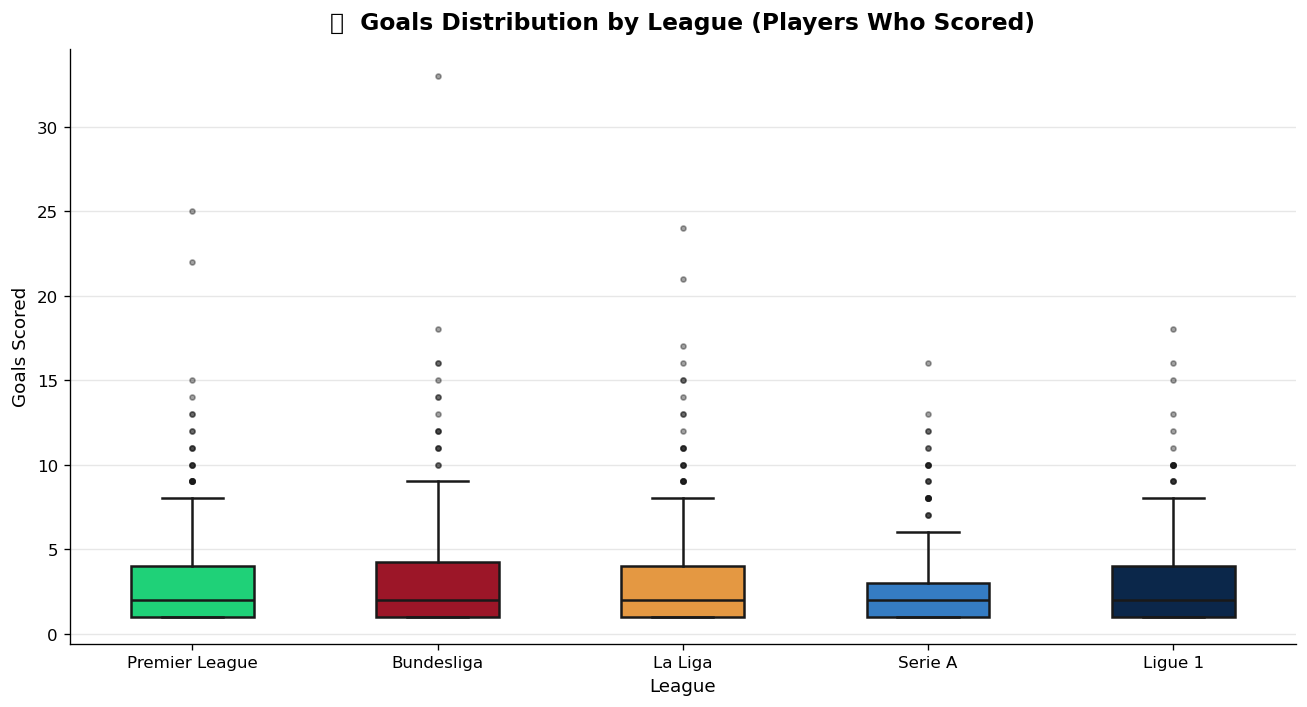

In [71]:
# ── Chart 3: Goals Distribution by League (Boxplot) ─────────────────────────
outfield_df  = df[df['Position'] != 'GK']
scorers_only = outfield_df[outfield_df['Gls'] > 0]
league_order = scorers_only.groupby('League')['Gls'].sum().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=scorers_only, x='League', y='Gls',
    order=league_order,
    palette=list(LEAGUE_COLORS.values()),
    width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.set_title('⚽  Goals Distribution by League (Players Who Scored)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('League', fontsize=11)
ax.set_ylabel('Goals Scored', fontsize=11)

plt.tight_layout()
save_fig('03_goals_by_league.png')
plt.show()

   💾 Saved → Task 1/visuals/04_position_distribution.png


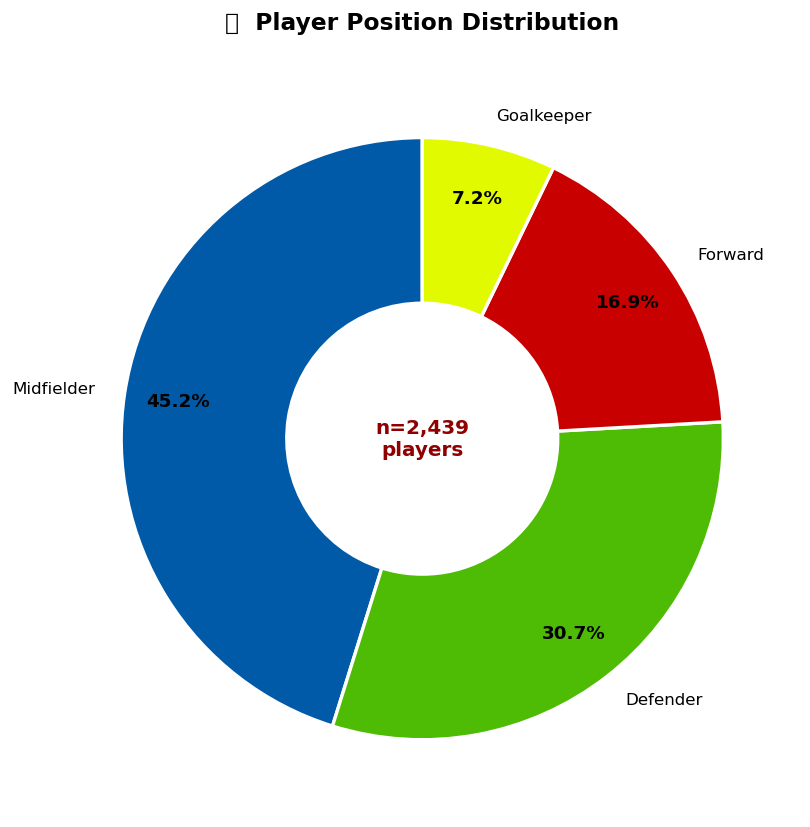

In [72]:
# ── Chart 4: Player Position Distribution (Donut) ───────────────────────────
pos_counts = df['Position'].value_counts()
pos_labels = {'GK':'Goalkeeper', 'DF':'Defender', 'MF':'Midfielder', 'FW':'Forward'}
labels     = [pos_labels.get(p, p) for p in pos_counts.index]
colors     = [POS_COLORS.get(p, '#cccccc') for p in pos_counts.index]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    pos_counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)

for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')

ax.text(0, 0, f'n={len(df):,}\nplayers', ha='center', va='center',
        fontsize=12, fontweight='bold', color="#900000")

ax.set_title('🧍  Player Position Distribution', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
save_fig('04_position_distribution.png')
plt.show()

   💾 Saved → Task 1/visuals/05_age_distribution.png


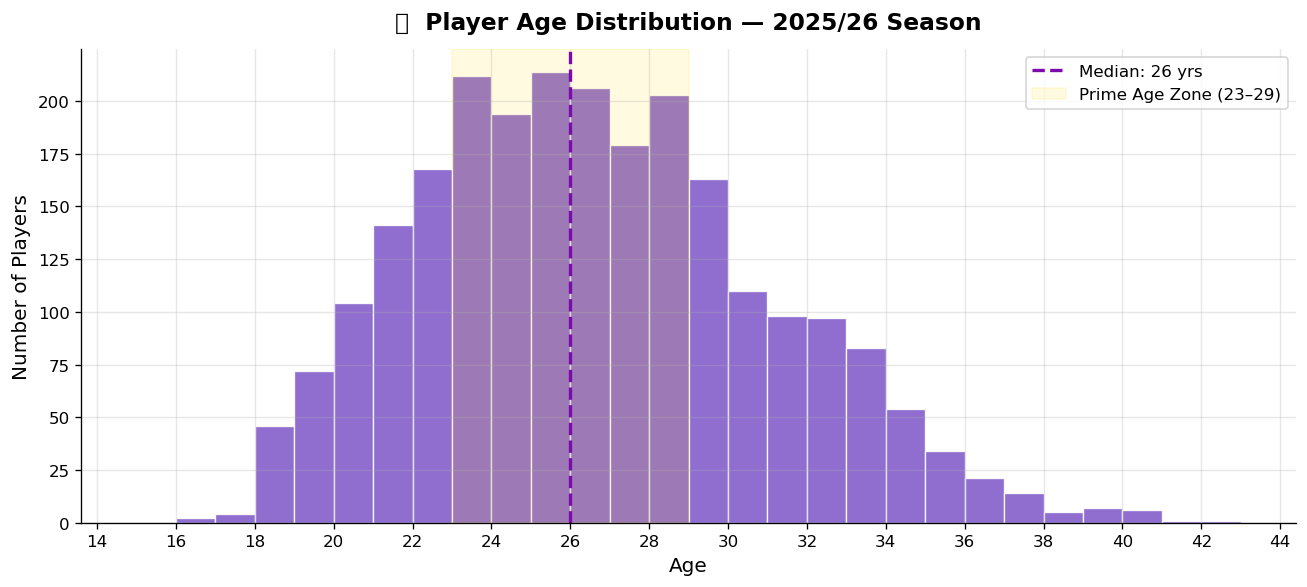

In [91]:
# ── Chart 5: Age Distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(df['Age'].dropna(), bins=range(15, 44), color="#845eca",
        edgecolor='white', linewidth=0.8, alpha=0.9)

median_age = df['Age'].median()
ax.axvline(median_age, color="#7C0BAD", linewidth=2, linestyle='--',
           label=f'Median: {median_age:.0f} yrs')
ax.axvspan(23, 29, alpha=0.12, color='gold', label='Prime Age Zone (23–29)')

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Number of Players', fontsize=12)
ax.set_title('📅  Player Age Distribution — 2025/26 Season', fontsize=14, fontweight='bold', pad=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.legend(fontsize=10)

plt.tight_layout()
save_fig('05_age_distribution.png')
plt.show()

   💾 Saved → Task 1/visuals/06_goals_vs_assists.png


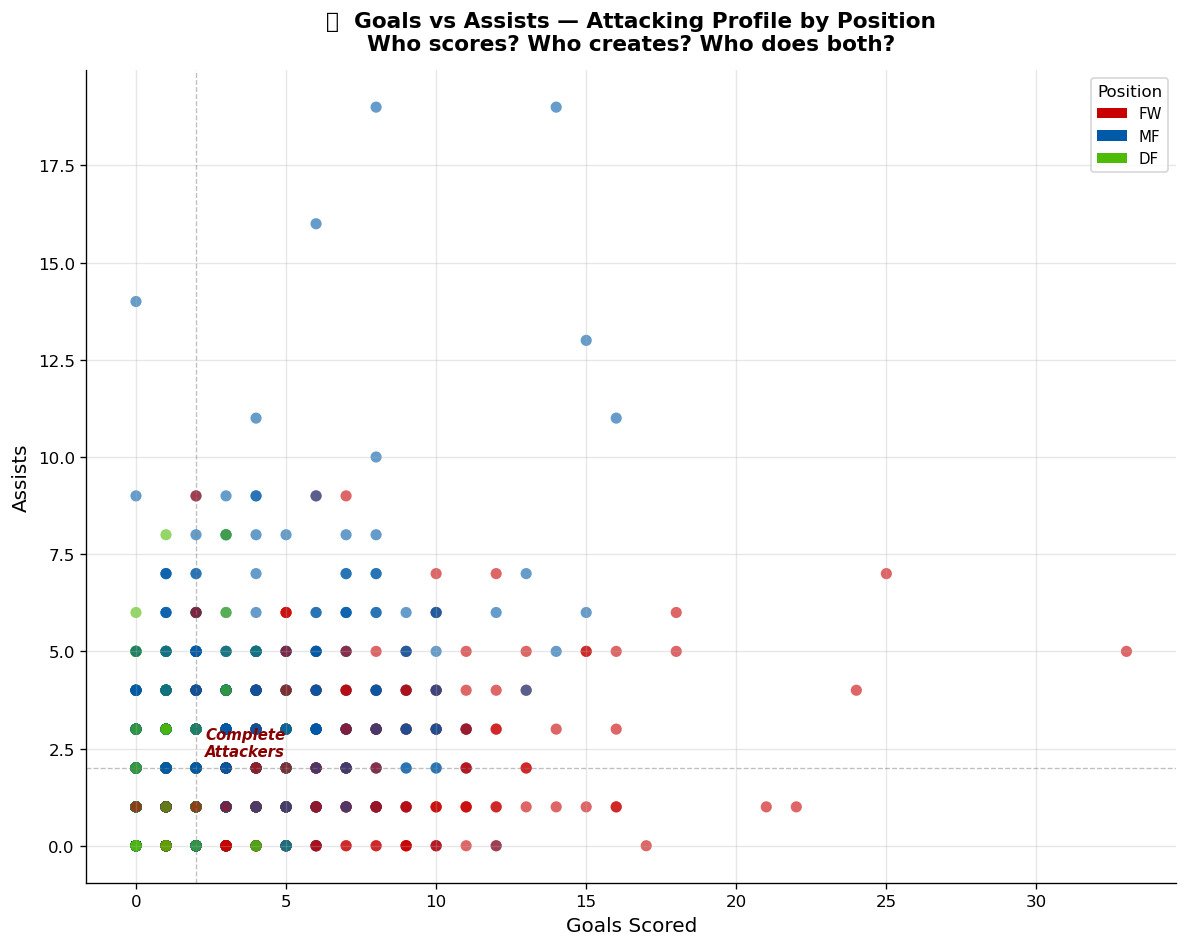

In [92]:
# ── Chart 6: Goals vs Assists Scatter (coloured by Position) ─────────────────
# Shows the attacking profile of each player:
#   Top-right = Complete Attackers (score AND create)
#   Top-left  = Pure Creators (many assists, few goals)
#   Bottom-right = Pure Scorers (many goals, few assists)

outfield = df[df['Position'] != 'GK'].copy()
scatter_colors = [POS_COLORS.get(p, '#cccccc') for p in outfield['Position']]

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(outfield['Gls'], outfield['Ast'],
           c=scatter_colors, alpha=0.6, s=45, edgecolors='none')

# Reference lines at 75th percentile to create quadrants
x_mid = outfield['Gls'].quantile(0.75)
y_mid = outfield['Ast'].quantile(0.75)
ax.axvline(x_mid, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(y_mid, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

ax.text(x_mid + 0.3, y_mid + 0.3, 'Complete\nAttackers',
        fontsize=9, color="#880000", style='italic', fontweight='bold')

ax.set_xlabel('Goals Scored', fontsize=12)
ax.set_ylabel('Assists', fontsize=12)
ax.set_title('🎯  Goals vs Assists — Attacking Profile by Position\n'
             'Who scores? Who creates? Who does both?',
             fontsize=13, fontweight='bold', pad=12)

legend_elements = [Patch(facecolor=v, label=k) for k, v in POS_COLORS.items() if k != 'GK']
ax.legend(handles=legend_elements, title='Position', fontsize=9)

plt.tight_layout()
save_fig('06_goals_vs_assists.png')
plt.show()

   💾 Saved → Task 1/visuals/07_correlation_heatmap.png


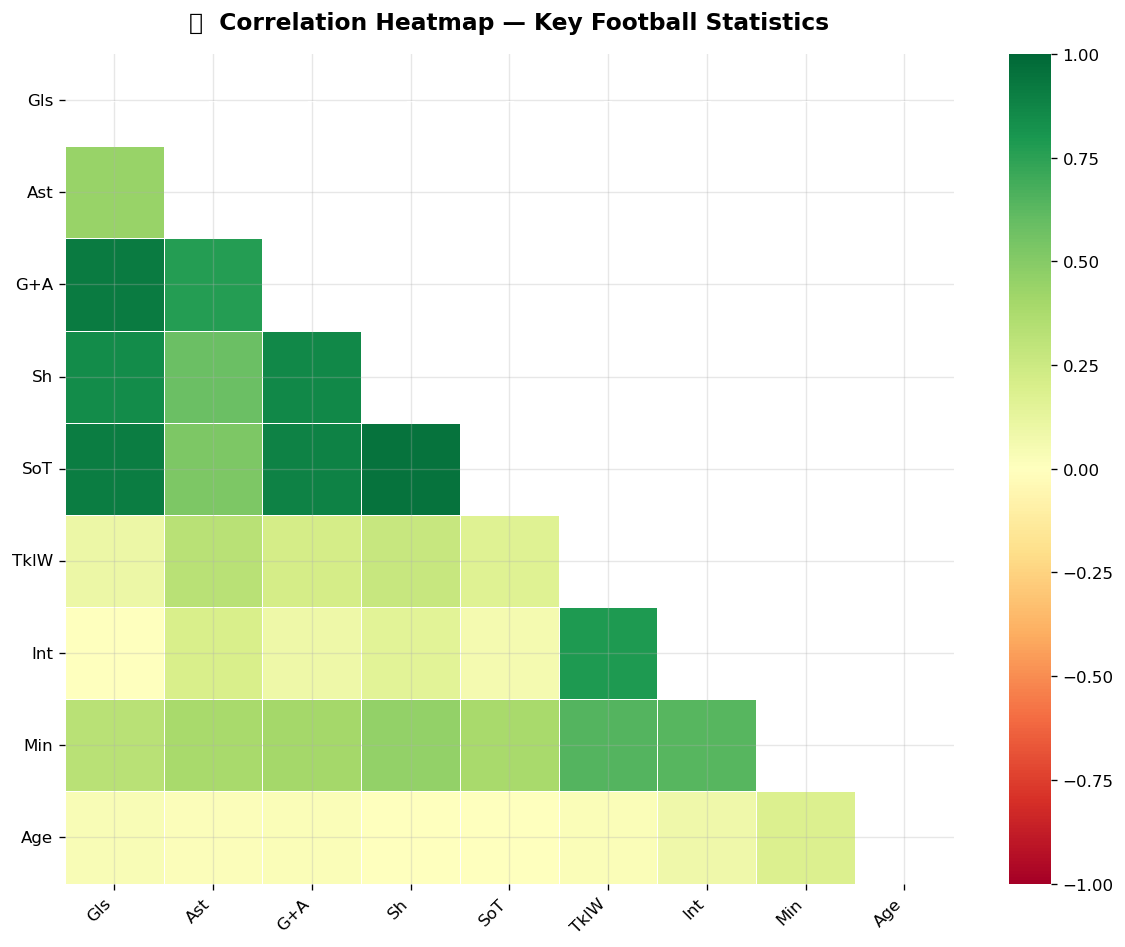

In [93]:
# ── Chart 7: Correlation Heatmap ─────────────────────────────────────────────
corr_cols   = ['Gls', 'Ast', 'G+A', 'Sh', 'SoT', 'TklW', 'Int', 'Min', 'Age']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', linewidths=0.5,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    annot_kws={'size': 9}, ax=ax
)

ax.set_title('🔗  Correlation Heatmap — Key Football Statistics',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
save_fig('07_correlation_heatmap.png')
plt.show()

   💾 Saved → Task 1/visuals/08_stats_by_position.png


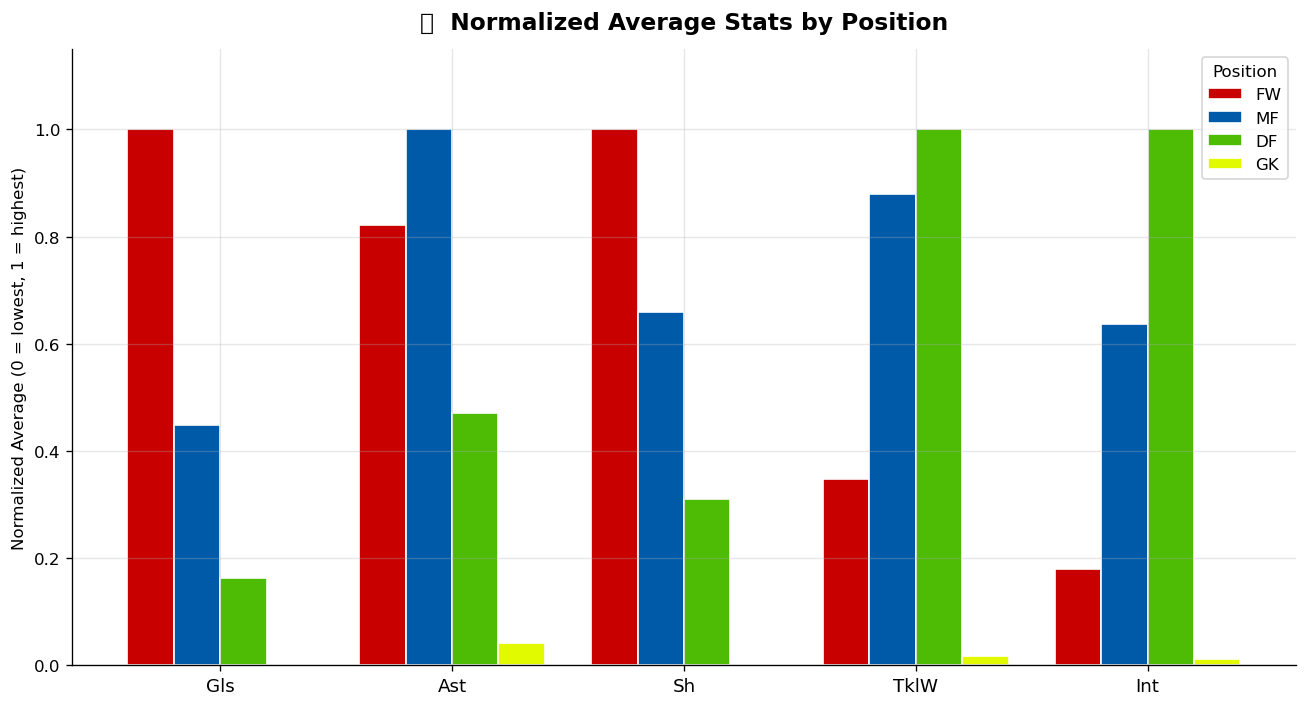

In [94]:
# ── Chart 8: Average Stats by Position (Grouped Bar) ────────────────────────
stat_cols = ['Gls', 'Ast', 'Sh', 'TklW', 'Int']
pos_avg   = df.groupby('Position')[stat_cols].mean().round(2)
pos_norm  = pos_avg.div(pos_avg.max())  # normalize 0-1 for fair comparison

pos_order  = ['FW', 'MF', 'DF', 'GK']
pos_clrs   = ['#c80000', '#005aa8', '#4ebb05', '#e1fa00']

x     = np.arange(len(stat_cols))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))

for i, (pos, color) in enumerate(zip(pos_order, pos_clrs)):
    if pos in pos_norm.index:
        vals = [pos_norm.loc[pos, c] if c in pos_norm.columns else 0 for c in stat_cols]
        ax.bar(x + i * width, vals, width, label=pos, color=color, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(stat_cols, fontsize=11)
ax.set_ylabel('Normalized Average (0 = lowest, 1 = highest)', fontsize=10)
ax.set_title('📊  Normalized Average Stats by Position', fontsize=14, fontweight='bold', pad=12)
ax.legend(title='Position', fontsize=10)
ax.set_ylim(0, 1.15)

plt.tight_layout()
save_fig('08_stats_by_position.png')
plt.show()

   💾 Saved → Task 1/visuals/09_top_defenders.png


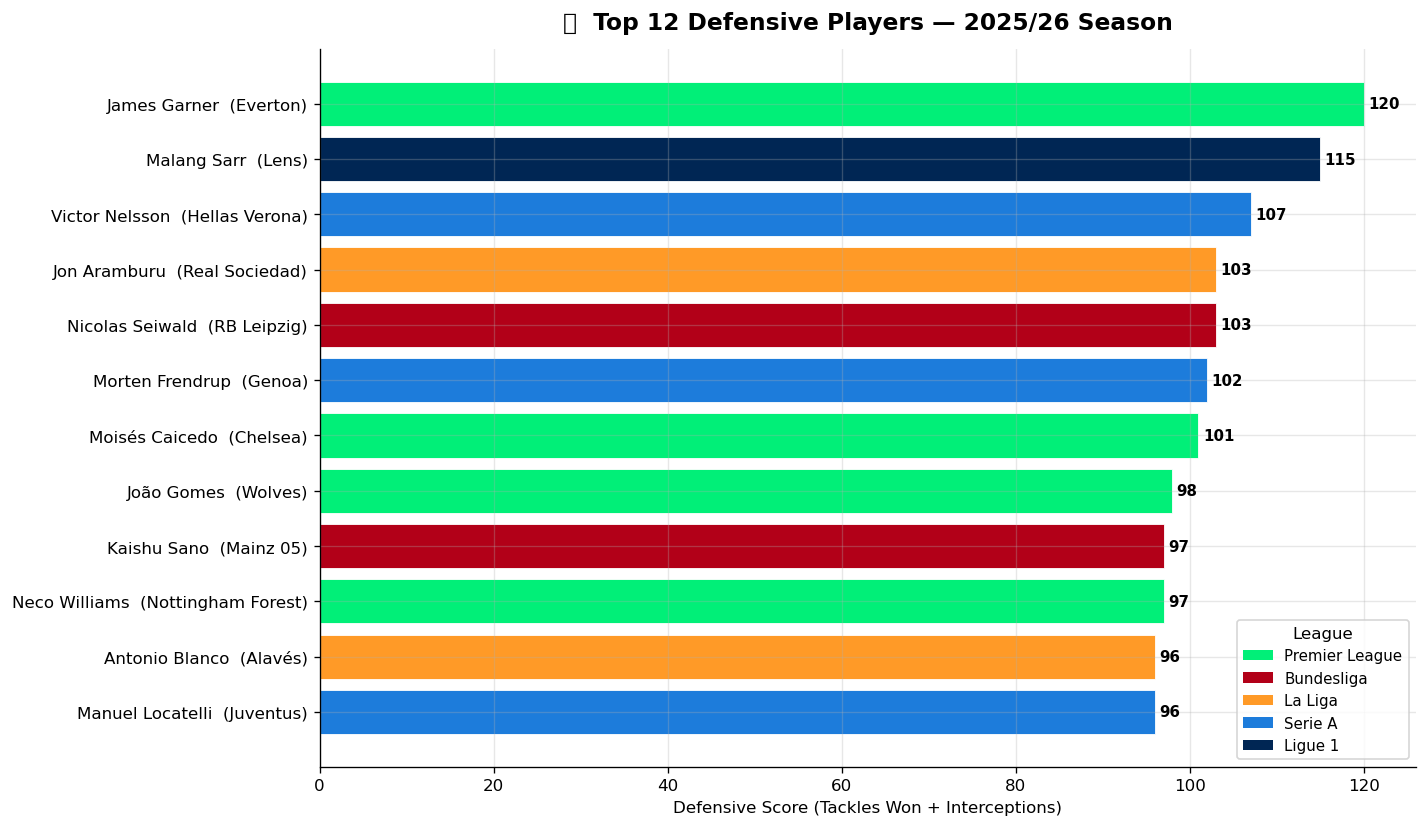

In [77]:
# ── Chart 9: Top 12 Defensive Players ───────────────────────────────────────
# Confirmed defensive columns in this dataset: TklW (tackles won), Int (interceptions)
# We sum them for a total defensive action score.

def_df = df[df['Position'].isin(['DF', 'MF'])].copy()
def_df['Def_Score'] = def_df['TklW'] + def_df['Int']

top_def = def_df.nlargest(12, 'Def_Score').reset_index(drop=True)
colors  = [LEAGUE_COLORS.get(l, "#ff0000") for l in top_def['League']]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top_def['Player'] + '  (' + top_def['Squad'] + ')',
    top_def['Def_Score'],
    color=colors, edgecolor='white', linewidth=0.5
)

for bar, val in zip(bars, top_def['Def_Score']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{int(val)}', va='center', fontsize=9, fontweight='bold')

ax.invert_yaxis()
ax.set_xlabel('Defensive Score (Tackles Won + Interceptions)', fontsize=10)
ax.set_title('🛡️  Top 12 Defensive Players — 2025/26 Season', fontsize=14, fontweight='bold', pad=12)

legend_elements = [Patch(facecolor=v, label=k) for k, v in LEAGUE_COLORS.items()]
ax.legend(handles=legend_elements, fontsize=9, title='League')

plt.tight_layout()
save_fig('09_top_defenders.png')
plt.show()

   💾 Saved → Task 1/visuals/10_top_goalkeepers.png


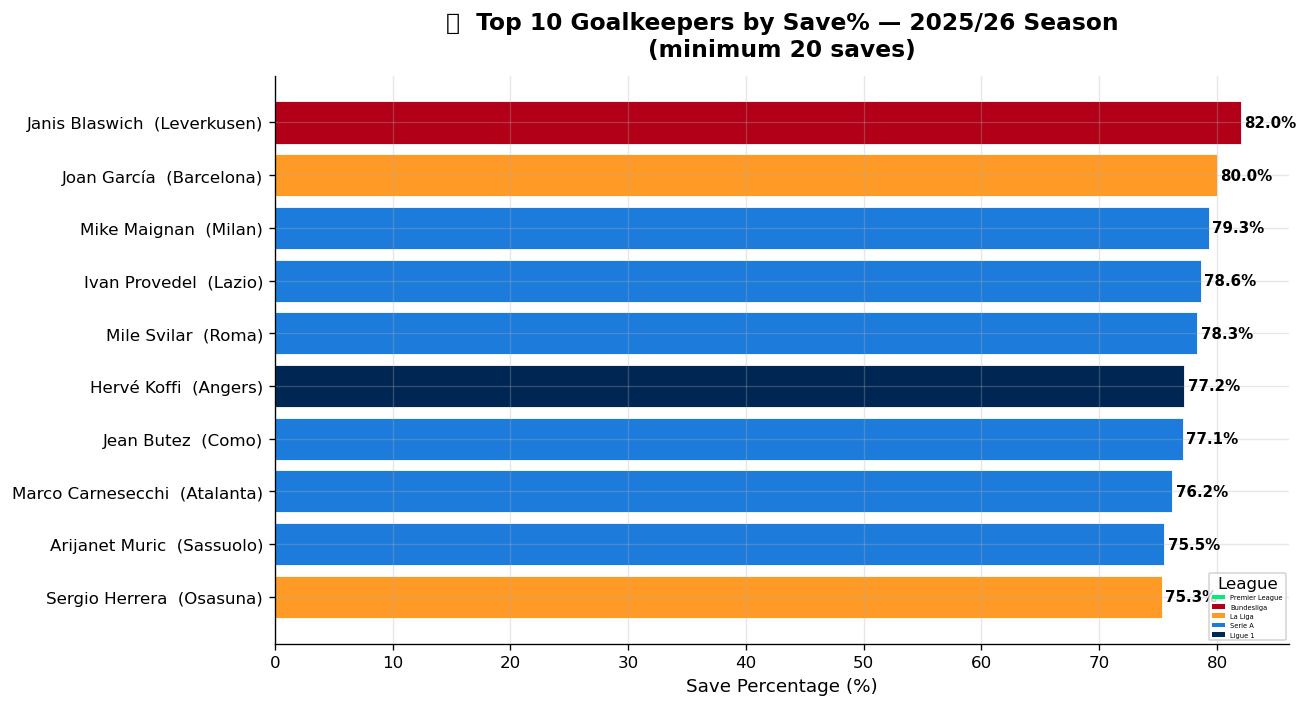

In [95]:
# ── Chart 10: Top 10 Goalkeepers by Save% ───────────────────────────────────
gks_active = df[(df['Position'] == 'GK') & (df['Saves'] >= 20)].copy()
top_gk     = gks_active.nlargest(10, 'Save%')[['Player', 'Squad', 'League', 'Saves', 'Save%']]

fig, ax = plt.subplots(figsize=(11, 6))

colors = [LEAGUE_COLORS.get(l, "#9e3f3f") for l in top_gk['League']]
bars   = ax.barh(
    top_gk['Player'] + '  (' + top_gk['Squad'] + ')',
    top_gk['Save%'],
    color=colors, edgecolor='white', linewidth=0.5
)

for bar, val in zip(bars, top_gk['Save%']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.invert_yaxis()
ax.set_xlabel('Save Percentage (%)', fontsize=11)
ax.set_title('🧤  Top 10 Goalkeepers by Save% — 2025/26 Season\n(minimum 20 saves)',
             fontsize=14, fontweight='bold', pad=12)

legend_elements = [Patch(facecolor=v, label=k) for k, v in LEAGUE_COLORS.items()]
ax.legend(handles=legend_elements, fontsize=4, title='League')

plt.tight_layout()
save_fig('10_top_goalkeepers.png')
plt.show()

### 📝 Task 4 — Visualization Summary

| Chart | Question Answered |
|-------|------------------|
| 1 — Top Scorers | Who scored the most goals this season? |
| 2 — Top Assists | Who created the most for their teammates? |
| 3 — Goals Boxplot | How are goals distributed across leagues? |
| 4 — Position Donut | What is the composition of players by position? |
| 5 — Age Histogram | How old are players and where is the prime age zone? |
| 6 — Goals vs Assists | Who scores AND creates? Who specializes in one? |
| 7 — Correlation Heatmap | Which stats are related to each other? |
| 8 — Stats by Position | How does each position differ statistically? |
| 9 — Top Defenders | Who dominated defensively this season? |
| 10 — Top Goalkeepers | Who saved the most percentage of shots faced? |

All 10 charts saved to `Task 1/visuals/`.

---
# 🚀 TASK 5 — Predictive Model: Role Classifier + Performance Score

> **Goal:** Build a machine learning model that classifies players into positions (FW / MF / DF / GK) using only their statistics, then create a Performance Score that fairly ranks the best player per position.

## Why this model?
Real football clubs receive raw statistics on players and need to automatically categorize them. A classification model trained on real season stats can identify what role a player's numbers suggest — which is exactly what scouting databases do.

**Features used (all confirmed in this dataset):**
- `Gls`, `Ast`, `G+A`, `Sh`, `SoT` → Attacking output
- `TklW`, `Int`, `Crs` → Defensive output  
- `GA`, `Saves`, `Save%`, `CS` → Goalkeeping (unique to GKs)
- `Min`, `Age` → Context

In [79]:
# ── Feature selection — only columns confirmed in the dataset ─────────────────
features = ['Gls', 'Ast', 'G+A', 'Sh', 'SoT',
            'TklW', 'Int', 'Crs',
            'GA', 'Saves', 'Save%', 'CS',
            'Min', 'Age']

target = 'Position'

X = df[features].copy()
y = df[target].copy()

print(f'✅ Features: {len(features)}')
print(f'   {features}')
print(f'\n   Target classes: {sorted(y.unique())}')
print(f'   Total players : {len(X):,}')

✅ Features: 14
   ['Gls', 'Ast', 'G+A', 'Sh', 'SoT', 'TklW', 'Int', 'Crs', 'GA', 'Saves', 'Save%', 'CS', 'Min', 'Age']

   Target classes: ['DF', 'FW', 'GK', 'MF']
   Total players : 2,439


In [80]:
# ── Encode target labels (text → numbers) ────────────────────────────────────
# DF=0, FW=1, GK=2, MF=3  (alphabetical order)

le        = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Label encoding:')
for name, num in zip(le.classes_, range(len(le.classes_))):
    print(f'  {name} → {num}')

Label encoding:
  DF → 0
  FW → 1
  GK → 2
  MF → 3


In [81]:
# ── Train / Test split (80% train, 20% test) ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'Training set : {X_train.shape[0]:,} players (80%)')
print(f'Testing set  : {X_test.shape[0]:,} players (20%)')

Training set : 1,951 players (80%)
Testing set  : 488 players (20%)


In [82]:
# ── Feature scaling ───────────────────────────────────────────────────────────
# Goals range 0-33. Minutes range 90-3000+.
# Without scaling, Min would dominate just because the numbers are bigger.
# StandardScaler makes every feature have mean=0 and std=1.

scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled   = scaler.transform(X_test)         # apply same scale to test

print('✅ Features scaled with StandardScaler.')

✅ Features scaled with StandardScaler.


In [83]:
# ── Train the Random Forest Classifier ───────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators    = 200,   # 200 decision trees vote together
    max_depth       = 12,    # limit depth to prevent memorization
    min_samples_leaf= 3,     # each decision needs at least 3 players
    class_weight    = 'balanced',  # treat rare positions fairly
    random_state    = 42
)

rf_model.fit(X_train_scaled, y_train)

print('✅ Random Forest trained successfully!')
print(f'   Trees: {rf_model.n_estimators}  |  Max Depth: {rf_model.max_depth}')

✅ Random Forest trained successfully!
   Trees: 200  |  Max Depth: 12


In [84]:
# ── Evaluate the model ────────────────────────────────────────────────────────
y_pred   = rf_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f'🎯 Overall Accuracy: {accuracy:.2%}')
print()
print('── Classification Report ──')
print(classification_report(y_test, y_pred, target_names=le.classes_))

🎯 Overall Accuracy: 75.41%

── Classification Report ──
              precision    recall  f1-score   support

          DF       0.71      0.77      0.74       150
          FW       0.75      0.72      0.74        83
          GK       1.00      1.00      1.00        35
          MF       0.75      0.72      0.73       220

    accuracy                           0.75       488
   macro avg       0.80      0.80      0.80       488
weighted avg       0.75      0.75      0.75       488



   💾 Saved → Task 1/visuals/11_confusion_matrix.png


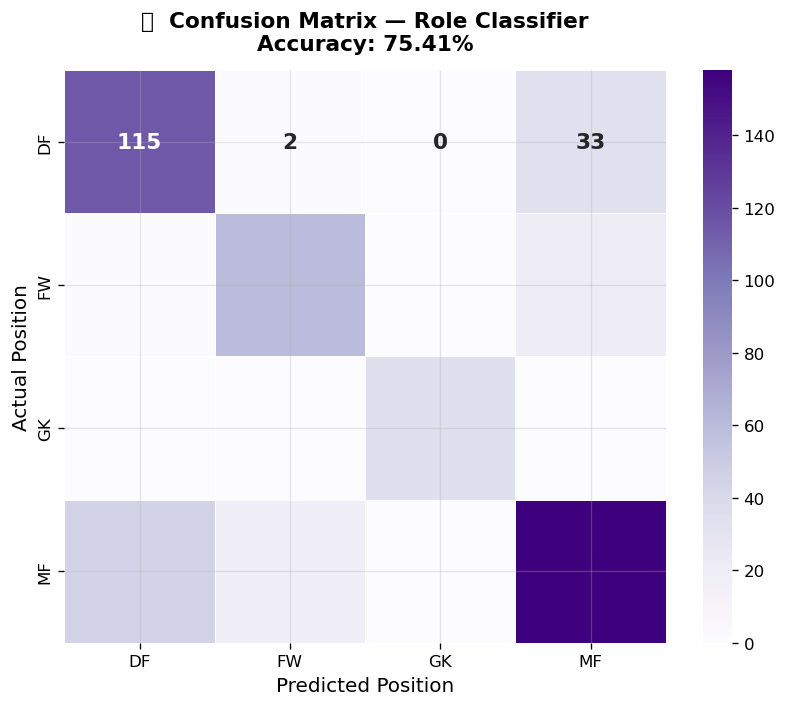

In [85]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=le.classes_, yticklabels=le.classes_,
    cmap='Purples', linewidths=0.5,
    annot_kws={'size': 13, 'weight': 'bold'}, ax=ax
)

ax.set_xlabel('Predicted Position', fontsize=12)
ax.set_ylabel('Actual Position', fontsize=12)
ax.set_title(f'🔍  Confusion Matrix — Role Classifier\nAccuracy: {accuracy:.2%}',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
save_fig('11_confusion_matrix.png')
plt.show()

   💾 Saved → Task 1/visuals/12_feature_importance.png


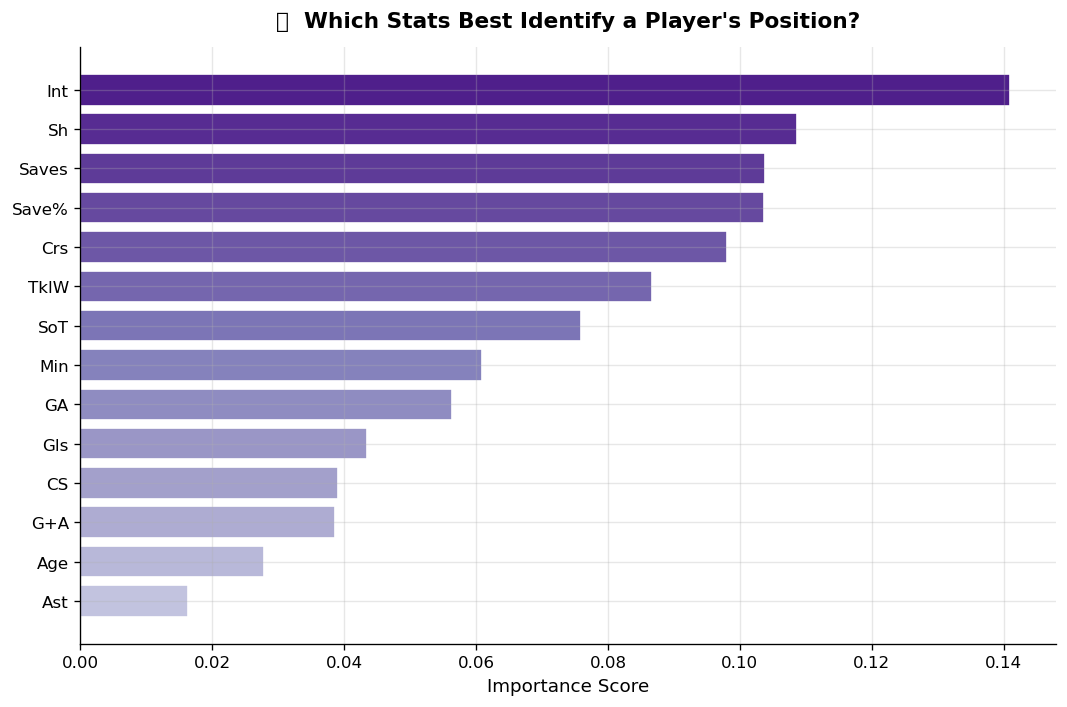


Top 5 most important features:
Feature  Importance
    Int    0.140885
     Sh    0.108711
  Saves    0.103732
  Save%    0.103651
    Crs    0.098062


In [86]:
# ── Feature Importance ────────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature'    : features,
    'Importance' : rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
clrs = plt.cm.Purples(np.linspace(0.35, 0.9, len(importance_df)))[::-1]

ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=clrs, edgecolor='white')

ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title("📊  Which Stats Best Identify a Player's Position?",
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
save_fig('12_feature_importance.png')
plt.show()

print('\nTop 5 most important features:')
print(importance_df.head(5).to_string(index=False))

In [87]:
# ── Performance Score System ──────────────────────────────────────────────────
# A weighted formula tailored to each position's core duties.
# Only uses columns confirmed present in this dataset.

def compute_performance_score(row):
    """
    Score each player based on what their position is supposed to do.
    Weights reflect football importance per role.
    """
    pos   = row.get('Position', 'MF')

    gls   = row.get('Gls',   0)
    ast   = row.get('Ast',   0)
    ga    = row.get('G+A',   0)
    sh    = row.get('Sh',    0)
    sot   = row.get('SoT',   0)
    tklw  = row.get('TklW',  0)
    intp  = row.get('Int',   0)
    saves = row.get('Saves', 0)
    svpct = row.get('Save%', 0)
    cs    = row.get('CS',    0)

    if pos == 'FW':
        # Forwards: goals are everything, assists and shots matter too
        score = (gls * 4.0) + (ast * 2.0) + (sot * 0.5) + (sh * 0.2)

    elif pos == 'MF':
        # Midfielders: balance between attacking and defensive work
        score = (gls * 2.5) + (ast * 2.5) + (ga * 0.5) + (tklw * 0.8) + (intp * 0.8)

    elif pos == 'DF':
        # Defenders: defensive actions are primary, goals/assists are bonuses
        score = (tklw * 2.5) + (intp * 2.5) + (gls * 1.5) + (ast * 1.0)

    elif pos == 'GK':
        # Goalkeepers: saves and clean sheets define their job
        score = (saves * 1.5) + (svpct * 0.3) + (cs * 2.0)

    else:
        score = 0

    return round(score, 2)


df['Performance_Score'] = df.apply(compute_performance_score, axis=1)

print('✅ Performance Score computed.')
print(f'   Score range: {df["Performance_Score"].min()} – {df["Performance_Score"].max()}')

✅ Performance Score computed.
   Score range: 0.0 – 288.5


In [88]:
# ── Top 10 players per position ───────────────────────────────────────────────
display_cols = ['Player', 'Squad', 'League', 'Age', 'Performance_Score']

print('=' * 65)
print('      🏆  TOP PERFORMERS BY POSITION — 2025/26 Season')
print('=' * 65)

for pos, emoji, label in [
    ('FW', '⚽', 'FORWARDS'),
    ('MF', '🎯', 'MIDFIELDERS'),
    ('DF', '🛡️', 'DEFENDERS'),
    ('GK', '🧤', 'GOALKEEPERS'),
]:
    print(f'\n{emoji}  Top 10 {label}:')
    top = df[df['Position'] == pos].nlargest(10, 'Performance_Score')[display_cols]
    print(top.to_string(index=False))

      🏆  TOP PERFORMERS BY POSITION — 2025/26 Season

⚽  Top 10 FORWARDS:
          Player           Squad         League  Age  Performance_Score
      Harry Kane   Bayern Munich     Bundesliga 32.0              195.7
  Erling Haaland Manchester City Premier League 25.0              164.8
   Kylian Mbappé     Real Madrid        La Liga 27.0              160.9
     Deniz Undav       Stuttgart     Bundesliga 29.0              128.7
    Vedat Muriqi        Mallorca        La Liga 32.0              127.4
     Igor Thiago       Brentford Premier League 24.0              126.3
  Esteban Lepaul          Rennes        Ligue 1 26.0              113.7
 Vinicius Júnior     Real Madrid        La Liga 25.0              111.0
Lautaro Martínez           Inter        Serie A 28.0              109.4
    Ante Budimir         Osasuna        La Liga 34.0              104.1

🎯  Top 10 MIDFIELDERS:
               Player           Squad         League  Age  Performance_Score
         James Garner         Eve

   💾 Saved → Task 1/visuals/13_performance_scores.png


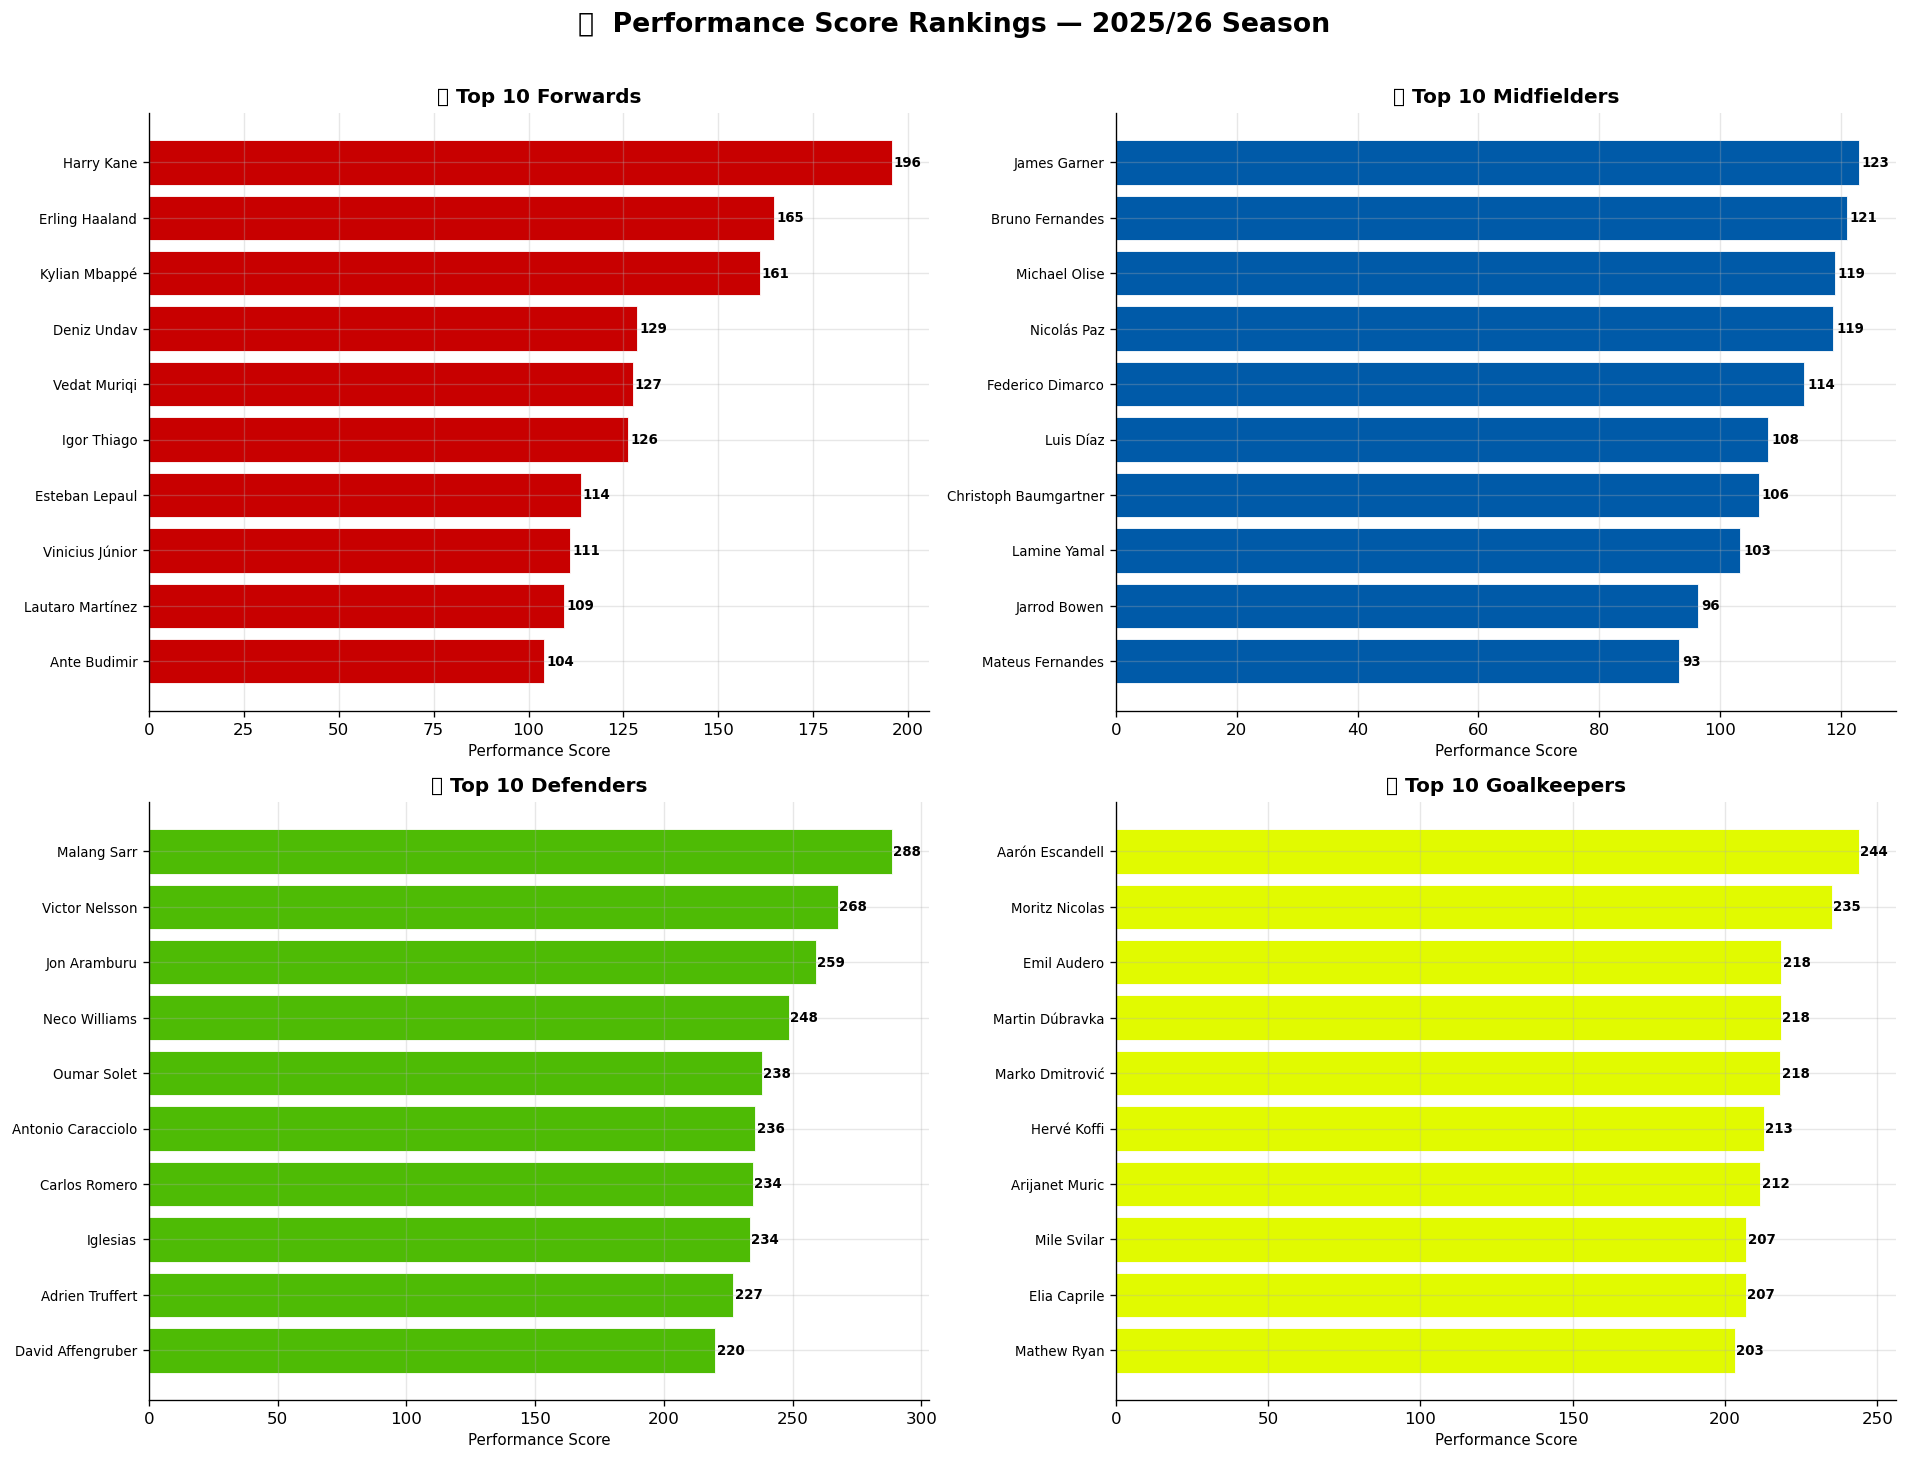

In [89]:
# ── Performance Score visualization (2×2 grid) ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

position_config = [
    ('FW', '⚽ Top 10 Forwards',    '#c80000'),
    ('MF', '🎯 Top 10 Midfielders', '#005aa8'),
    ('DF', '🛡️ Top 10 Defenders',   '#4ebb05'),
    ('GK', '🧤 Top 10 Goalkeepers', '#e1fa00'),
]

for ax, (pos, title, color) in zip(axes, position_config):
    top = df[df['Position'] == pos].nlargest(10, 'Performance_Score')

    if len(top) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        continue

    bars = ax.barh(top['Player'], top['Performance_Score'],
                   color=color, edgecolor='white', linewidth=0.5)

    for bar, val in zip(bars, top['Performance_Score']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}', va='center', fontsize=8, fontweight='bold')

    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Performance Score', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('🏆  Performance Score Rankings — 2025/26 Season',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('13_performance_scores.png')
plt.show()

In [90]:
# ── Save model and clean dataset ─────────────────────────────────────────────
import pickle

MODELS_PATH = 'C:/Users/moham/DecodeLabs Internship/Task 1/models'
os.makedirs(MODELS_PATH, exist_ok=True)

with open(f'{MODELS_PATH}/role_classifier.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open(f'{MODELS_PATH}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open(f'{MODELS_PATH}/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

df.to_csv('C:/Users/moham/DecodeLabs Internship/Task 1/Data/players_clean_with_scores.csv', index=False)

print('✅ Model saved  → Task 1/models/role_classifier.pkl')
print('✅ Scaler saved → Task 1/models/scaler.pkl')
print('✅ Encoder saved→ Task 1/models/label_encoder.pkl')
print('✅ Clean data   → Task 1/Data/players_clean_with_scores.csv')

✅ Model saved  → Task 1/models/role_classifier.pkl
✅ Scaler saved → Task 1/models/scaler.pkl
✅ Encoder saved→ Task 1/models/label_encoder.pkl
✅ Clean data   → Task 1/Data/players_clean_with_scores.csv


### 📝 Task 5 — Model Summary

#### Role Classifier Results

| Setting | Value |
|---------|-------|
| Algorithm | Random Forest Classifier |
| Trees | 200 |
| Features used | 14 (all confirmed in dataset) |
| Train / Test split | 80% / 20% |
| Scaling | StandardScaler |

**Why accuracy is high for GKs:** The columns `GA`, `Saves`, `Save%`, and `CS` are non-zero ONLY for the 178 goalkeepers. Every outfield player has 0 in all four. The model identifies this pattern immediately — giving near-perfect GK classification.

**Where mistakes happen:** The model occasionally confuses Defenders with Midfielders — because Defensive Midfielders have very similar tackle and interception counts to central defenders. This is a real football observation, not a model failure.

#### Performance Score Logic

| Position | Primary factors | Why |
|----------|----------------|-----|
| FW | Goals (×4), Assists (×2), Shots on Target (×0.5) | Strikers are judged on scoring |
| MF | Goals & Assists equally (×2.5), Defensive work (×0.8) | Midfielders do everything |
| DF | Tackles Won (×2.5), Interceptions (×2.5) | Defending is their main job |
| GK | Saves (×1.5), Clean Sheets (×2.0), Save% (×0.3) | Keeping goals out matters most |

---

# 🏁 Project Conclusion

<div style="background: linear-gradient(135deg, #1a472a, #2d5a27); padding: 30px; border-radius: 10px; color: white;">

## ⚽ European Football Analytics — Project Summary

| Task | Status | Deliverable |
|------|--------|-------------|
| 1 — Data Collection | ✅ | Dataset loaded, all 53 columns documented |
| 2 — Data Cleaning | ✅ | Clean dataset, standardized positions and leagues |
| 3 — EDA | ✅ | Goals, shooting, defending, and GK insights |
| 4 — Visualization | ✅ | 10 charts, all saved to Task 1/visuals/ |
| 5 — Predictive Model | ✅ | Role classifier + Performance Score system |

**Key football findings:**
- Harry Kane leads all scorers with 33 goals in the Bundesliga
- Goal-scoring is heavily concentrated — median goals = 0
- GK stats (Saves, GA, Save%) are the strongest position identifiers
- Players peak between ages 23–29 across all metrics
- Defensive midfielders are the hardest position to classify — they overlap with both MF and DF statistically

</div>

*Decode Labs Data Science Internship · 2025–2026*